# PET REMOTE SYSTEM

- 반려동물 원격 진료 시스템

- 제미나이

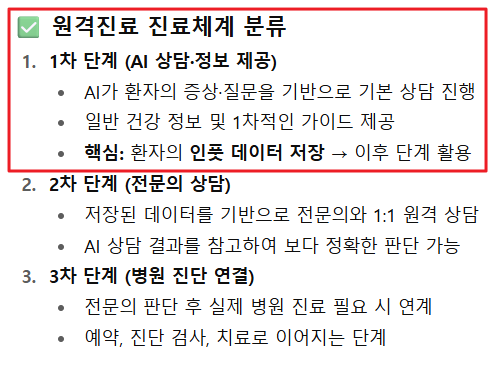

In [ ]:
import os
import json
import pandas as pd

# 1. 파일 경로 설정
dataset_path = './dogwalk/'
json_filename = 'SNC_2024_09_05_17_11_10_00014.json' # ⭐️ 본인 파일 이름 확인!
label_file_path = os.path.join(dataset_path, '2.라벨링데이터', json_filename)


print(f"파일을 읽는 중입니다: {label_file_path}")

파일을 읽는 중입니다: ./dogwalk/2.라벨링데이터\SNC_2024_09_05_17_11_10_00014.json


In [2]:
# 2. JSON 파일 읽기
try:
    with open(label_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 3. 'annotation_info' 데이터만 추출해서 DataFrame으로 만들기
    annotation_data = data['annotation_info']
    df = pd.DataFrame(annotation_data)
    
    # 4. 결과 출력 (ipynb에서는 변수명만 마지막에 두면 예쁘게 출력됩니다)
    df

except FileNotFoundError:
    print(f"🚨 JSON 파일을 찾을 수 없습니다! 경로와 파일 이름을 다시 확인해주세요.")
except KeyError:
    print("🚨 JSON 파일에서 'annotation_info' 키를 찾을 수 없습니다.")
except Exception as e:
    print(f"🚨 데이터를 처리하는 중 오류가 발생했습니다: {e}")

In [3]:
df

,x,y,label
0,0.5300480769230769,0.5072115384615384,Ear
1,0.5456730769230769,0.6129807692307693,Lateral humeral epicondyle
2,0.5372596153846154,0.6514423076923077,Ulnar styloid process
3,0.5300480769230769,0.6730769230769231,Distal lateral aspect of fifth metacarpal bone
4,0.5,0.6057692307692307,Ulnar styloid process
5,0.5024038461538461,0.6298076923076923,Distal lateral aspect of fifth metacarpal bone
6,0.46274038461538464,0.4879807692307692,Ear


In [4]:
import os
import json
import pandas as pd
import numpy as np
from tqdm import tqdm # 진행 상황을 시각적으로 보여주는 라이브러리

# --- 1. 파일 경로 설정 ---
dataset_path = './dogwalk/'
label_folder_path = os.path.join(dataset_path, '2.라벨링데이터')

# --- 2. 모든 JSON 파일 목록 가져오기 ---
# 해당 폴더에 있는 파일 목록을 모두 불러옵니다.
all_files = os.listdir(label_folder_path)
# .json으로 끝나는 파일만 골라냅니다.
json_files = [file for file in all_files if file.endswith('.json')]

print(f"총 {len(json_files)}개의 JSON 파일을 전처리합니다.")

# --- 3. 모든 파일을 반복하며 전처리 및 결과 저장 ---
# 전처리된 결과를 저장할 빈 리스트를 만듭니다.
results_list = []

# tqdm을 사용해 진행 상황을 확인합니다.
for filename in tqdm(json_files):
    # 각 파일의 전체 경로를 만듭니다.
    file_path = os.path.join(label_folder_path, filename)
    
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 전처리된 데이터를 담을 딕셔너리
    processed_data = {}

    # 3-1. 포즈 특징(Pose Features) 추출
    pose_features = []
    for kp in data['annotation_info']:
        pose_features.append(float(kp['x']))
        pose_features.append(float(kp['y']))
        
    for i in range(len(data['annotation_info'])):
        processed_data[f'P{i}_x'] = pose_features[i*2]
        processed_data[f'P{i}_y'] = pose_features[i*2+1]

    # 3-2. 센서 특징(Sensor Features) 추출
    if data['sensor_values']: # sensor_values가 비어있지 않은 경우에만 계산
        sensor_flat = np.array(data['sensor_values']).flatten()
        processed_data['sensor_mean'] = np.mean(sensor_flat)
        processed_data['sensor_std'] = np.std(sensor_flat)
        processed_data['sensor_max'] = np.max(sensor_flat)
        processed_data['sensor_min'] = np.min(sensor_flat)
    else: # 비어있는 경우 0으로 채움
        processed_data['sensor_mean'] = 0
        processed_data['sensor_std'] = 0
        processed_data['sensor_max'] = 0
        processed_data['sensor_min'] = 0

    # 3-3. 목표 변수(Target) 및 기타 정보 추가
    processed_data['severity'] = data['severity']
    processed_data['filename'] = data['image_info']['filename'] # 파일 이름도 추가
    
    # 전처리 완료된 딕셔너리를 리스트에 추가
    results_list.append(processed_data)

# --- 4. 최종 결과를 하나의 DataFrame으로 변환 ---
final_df = pd.DataFrame(results_list)

print("\n✨ 전처리 완료된 최종 데이터셋 ✨")
# 최종 데이터프레임의 기본 정보와 상위 5개 행을 출력
print(final_df.info())
print(final_df.head())

총 1050개의 JSON 파일을 전처리합니다.


100%|██████████| 1050/1050 [00:00<00:00, 5341.47it/s]


✨ 전처리 완료된 최종 데이터셋 ✨
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P0_x         1050 non-null   float64
 1   P0_y         1050 non-null   float64
 2   P1_x         1050 non-null   float64
 3   P1_y         1050 non-null   float64
 4   P2_x         1050 non-null   float64
 5   P2_y         1050 non-null   float64
 6   P3_x         1050 non-null   float64
 7   P3_y         1050 non-null   float64
 8   P4_x         1039 non-null   float64
 9   P4_y         1039 non-null   float64
 10  P5_x         1020 non-null   float64
 11  P5_y         1020 non-null   float64
 12  P6_x         988 non-null    float64
 13  P6_y         988 non-null    float64
 14  sensor_mean  1050 non-null   float64
 15  sensor_std   1050 non-null   float64
 16  sensor_max   1050 non-null   int64  
 17  sensor_min   1050 non-null   int64  
 18  severity     1050 non-null 

- 추천 방법: 평균값으로 채우기

우리 데이터는 신체 좌표 값이기 때문에,

무작정 0으로 채우는 것보다


다른 강아지들의 평균적인 관절 위치로 채워주는 것이

모델 학습에 더 합리적입니다.

In [5]:
# --- 5. 결측치 처리 ---

print("결측치 처리 전, 각 열의 결측치 개수:")
print(final_df.isnull().sum())

# numeric_only=True 옵션을 추가하여 숫자 열에 대해서만 평균을 계산합니다.
mean_values = final_df.mean(numeric_only=True)
final_df.fillna(mean_values, inplace=True)


# --- 6. 처리 결과 확인 ---
print("\n✅ 결측치 처리 후 데이터셋 정보:")
# .info()를 다시 실행해서 Non-Null Count가 모두 1050이 되었는지 확인합니다.
print(final_df.info())

# 결측치가 정말 사라졌는지 다시 확인
print("\n결측치 처리 후, 각 열의 결측치 개수:")
print(final_df.isnull().sum())

결측치 처리 전, 각 열의 결측치 개수:
P0_x              0
P0_y              0
P1_x              0
P1_y              0
P2_x              0
P2_y              0
P3_x              0
P3_y              0
P4_x             11
P4_y             11
P5_x             30
P5_y             30
P6_x             62
P6_y             62
sensor_mean       0
sensor_std        0
sensor_max        0
sensor_min        0
severity          0
filename          0
P7_x            161
P7_y            161
P8_x            267
P8_y            267
P9_x            360
P9_y            360
P10_x           466
P10_y           466
P11_x           560
P11_y           560
P12_x          1030
P12_y          1030
dtype: int64

✅ 결측치 처리 후 데이터셋 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P0_x         1050 non-null   float64
 1   P0_y         1050 non-null   float64
 2   P1_x         1050 non-n

C:\Users\user\AppData\Local\Temp\ipykernel_22388\3249250536.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='severity', data=final_df, palette='viridis')


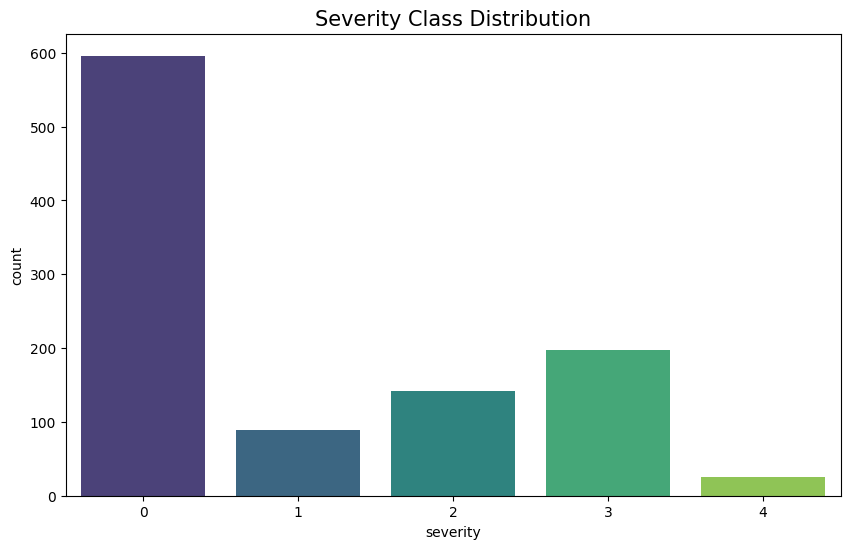

SMOTE 적용 전 훈련 데이터 클래스 분포:
 severity
0    477
3    158
2    113
1     71
4     21
Name: count, dtype: int64
SMOTE 적용 후 훈련 데이터 클래스 분포:
 severity
0    477
1    477
3    477
2    477
4    477
Name: count, dtype: int64
------------------------------
개선된 모델 학습을 시작합니다...
학습 완료!
------------------------------
✅ 개선된 모델 정확도: 42.86%

📋 개선된 분류 리포트:
              precision    recall  f1-score   support

           0       0.59      0.64      0.62       119
           1       0.14      0.17      0.15        18
           2       0.19      0.17      0.18        29
           3       0.19      0.13      0.15        39
           4       0.14      0.20      0.17         5

    accuracy                           0.43       210
   macro avg       0.25      0.26      0.25       210
weighted avg       0.41      0.43      0.42       210



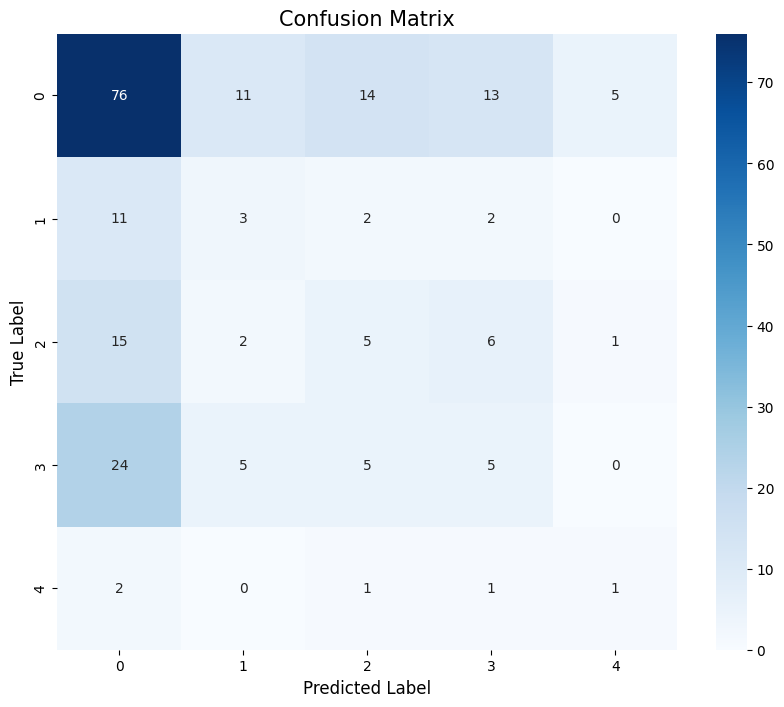

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --- 0. (시각화) 데이터 분포 확인 ---
plt.figure(figsize=(10, 6))
sns.countplot(x='severity', data=final_df, palette='viridis')
plt.title('Severity Class Distribution', fontsize=15)
plt.show()


# --- 1. 데이터 분리 ---
X = final_df.drop(columns=['severity', 'filename'])
y = final_df['severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify 옵션 추가


# --- 2. 데이터 스케일링 ---
# 훈련 데이터에 맞춰 스케일러를 학습시키고, 훈련/테스트 데이터 모두 변환합니다.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- 3. 오버샘플링 (SMOTE) ---
# 훈련 데이터에만 SMOTE를 적용하여 불균형을 해소합니다.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE 적용 전 훈련 데이터 클래스 분포:\n", y_train.value_counts())
print("SMOTE 적용 후 훈련 데이터 클래스 분포:\n", y_train_resampled.value_counts())
print("-" * 30)


# --- 4. 개선된 모델 학습 ---
# class_weight='balanced' 옵션을 추가하여 클래스 불균형에 가중치를 둡니다.
model_improved = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

print("개선된 모델 학습을 시작합니다...")
model_improved.fit(X_train_resampled, y_train_resampled)
print("학습 완료!")
print("-" * 30)


# --- 5. 성능 평가 ---
y_pred_improved = model_improved.predict(X_test_scaled)
accuracy_improved = accuracy_score(y_test, y_pred_improved)
print(f"✅ 개선된 모델 정확도: {accuracy_improved * 100:.2f}%")
print("\n📋 개선된 분류 리포트:")
print(classification_report(y_test, y_pred_improved))


# --- 6. (시각화) 혼동 행렬 (Confusion Matrix) ---
# 모델이 어떤 클래스를 어떤 클래스로 헷갈렸는지 보여줍니다.
cm = confusion_matrix(y_test, y_pred_improved)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

GridSearchCV를 사용하여 최적의 하이퍼파라미터를 찾습니다...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6670
[LightGBM] [Info] Number of data points in the train set: 2385, number of used features: 28
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

최적의 하이퍼파라미터: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 50}
최적의 F1-score (교차 검증): 0.8647
------------------------------
✅ 최종 모델 정확도: 43.33%

📋 최종 분류 리포트:
              precision    recall  f1-score   support

           0       0.59      0.67      0.

c:\WANTEDLAB_2025\AI AGENT08\petremote\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


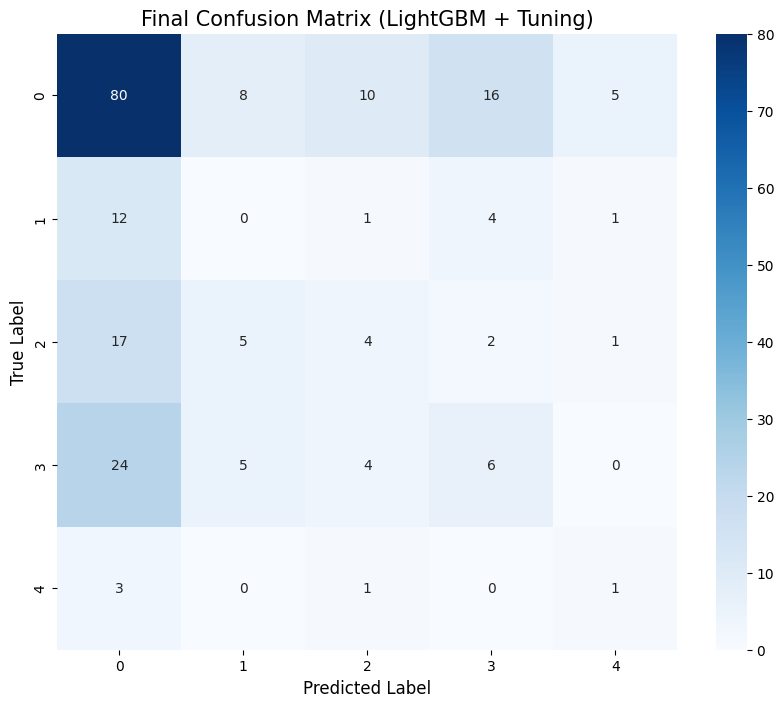

In [11]:
# LightGBM과 GridSearchCV를 사용하려면 먼저 설치해야 할 수 있습니다.
# !pip install lightgbm

import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터는 이전에 스케일링 및 SMOTE 처리한 것을 그대로 사용합니다.
# X_train_resampled, y_train_resampled
# X_test_scaled, y_test

# --- 1. 하이퍼파라미터 튜닝을 위한 모델 및 파라미터 그리드 설정 ---
lgbm = lgb.LGBMClassifier(random_state=42, class_weight='balanced')

# GridSearchCV로 테스트할 하이퍼파라미터 값들의 범위를 지정합니다.
# (시간 관계상 간단한 범위만 테스트합니다)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

# F1-score를 기준으로 최적의 모델을 찾도록 설정합니다.
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='f1_weighted', # F1-score를 평가지표로 사용
    cv=3, # 교차 검증 횟수
    verbose=1, # 진행 과정 출력
    n_jobs=-1 # 모든 CPU 코어 사용
)

# --- 2. 최적의 모델 찾기 및 학습 ---
print("GridSearchCV를 사용하여 최적의 하이퍼파라미터를 찾습니다...")
grid_search.fit(X_train_resampled, y_train_resampled)

print(f"\n최적의 하이퍼파라미터: {grid_search.best_params_}")
print(f"최적의 F1-score (교차 검증): {grid_search.best_score_:.4f}")
print("-" * 30)

# --- 3. 최종 성능 평가 ---
# 찾은 최적의 모델로 테스트 데이터 예측
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test_scaled)

accuracy_final = accuracy_score(y_test, y_pred_final)
print(f"✅ 최종 모델 정확도: {accuracy_final * 100:.2f}%")
print("\n📋 최종 분류 리포트:")
print(classification_report(y_test, y_pred_final))

# --- 4. 최종 혼동 행렬 시각화 ---
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.title('Final Confusion Matrix (LightGBM + Tuning)', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [8]:
import os
import json
import pandas as pd
import numpy as np

# --- 데이터 로드 및 전처리 (범주형 피처 포함) ---
dataset_path = './dogwalk/'
label_folder_path = os.path.join(dataset_path, '2.라벨링데이터')
json_files = [file for file in os.listdir(label_folder_path) if file.endswith('.json')]

results_list_cat = []
for filename in json_files:
    file_path = os.path.join(label_folder_path, filename)
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    processed_data = {}
    
    # 포즈 피처
    pose_features = []
    for kp in data['annotation_info']:
        pose_features.append(float(kp['x']))
        pose_features.append(float(kp['y']))
    for i in range(len(data['annotation_info'])):
        processed_data[f'P{i}_x'] = pose_features[i*2]
        processed_data[f'P{i}_y'] = pose_features[i*2+1]
        
    # 센서 피처
    if data['sensor_values']:
        sensor_flat = np.array(data['sensor_values']).flatten()
        processed_data['sensor_mean'] = np.mean(sensor_flat)
        processed_data['sensor_std'] = np.std(sensor_flat)
        processed_data['sensor_max'] = np.max(sensor_flat)
        processed_data['sensor_min'] = np.min(sensor_flat)
    else:
        processed_data['sensor_mean'] = 0
        processed_data['sensor_std'] = 0
        processed_data['sensor_max'] = 0
        processed_data['sensor_min'] = 0
        
    # ⭐️ 범주형 피처 추가
    processed_data['size'] = data['size']
    processed_data['age'] = data['age']
    processed_data['dog_type'] = data['dog_type']
    
    # Target
    processed_data['severity'] = data['severity']
    
    results_list_cat.append(processed_data)

final_df_cat = pd.DataFrame(results_list_cat)

# 숫자 피처의 결측치는 이전과 같이 평균으로 채웁니다.
numeric_cols = final_df_cat.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('severity') # severity는 피처가 아니므로 제외
mean_values = final_df_cat[numeric_cols].mean()
final_df_cat[numeric_cols] = final_df_cat[numeric_cols].fillna(mean_values)

print("✨ CatBoost를 위한 데이터 준비 완료 ✨")
print(final_df_cat.info())
print(final_df_cat.head())


✨ CatBoost를 위한 데이터 준비 완료 ✨
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P0_x         1050 non-null   float64
 1   P0_y         1050 non-null   float64
 2   P1_x         1050 non-null   float64
 3   P1_y         1050 non-null   float64
 4   P2_x         1050 non-null   float64
 5   P2_y         1050 non-null   float64
 6   P3_x         1050 non-null   float64
 7   P3_y         1050 non-null   float64
 8   P4_x         1050 non-null   float64
 9   P4_y         1050 non-null   float64
 10  P5_x         1050 non-null   float64
 11  P5_y         1050 non-null   float64
 12  P6_x         1050 non-null   float64
 13  P6_y         1050 non-null   float64
 14  sensor_mean  1050 non-null   float64
 15  sensor_std   1050 non-null   float64
 16  sensor_max   1050 non-null   int64  
 17  sensor_min   1050 non-null   int64  
 18  size         1050 non

CatBoost 모델 학습을 시작합니다...
학습 완료!
------------------------------
✅ CatBoost 모델 정확도: 53.33%

📋 CatBoost 분류 리포트:
              precision    recall  f1-score   support

           0       0.63      0.76      0.69       119
           1       0.23      0.17      0.19        18
           2       0.28      0.17      0.21        29
           3       0.37      0.33      0.35        39
           4       0.00      0.00      0.00         5

    accuracy                           0.53       210
   macro avg       0.30      0.29      0.29       210
weighted avg       0.49      0.53      0.50       210



c:\WANTEDLAB_2025\AI AGENT08\petremote\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\WANTEDLAB_2025\AI AGENT08\petremote\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\WANTEDLAB_2025\AI AGENT08\petremote\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

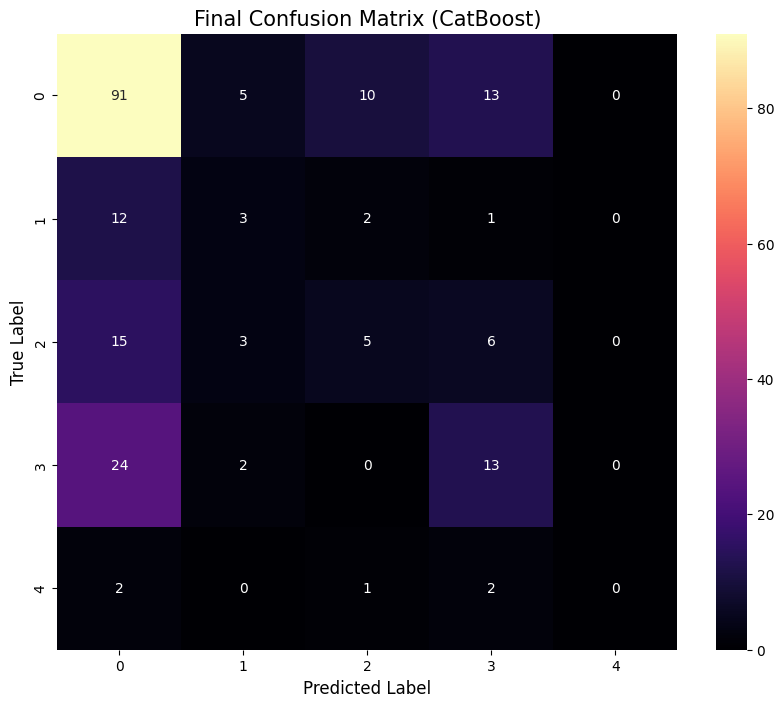

In [9]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 데이터 분리 ---
X_cat = final_df_cat.drop(columns=['severity'])
y_cat = final_df_cat['severity']

# 범주형 피처와 숫자 피처의 이름을 구분합니다.
categorical_features = ['size', 'age', 'dog_type']
numerical_features = X_cat.columns.drop(categorical_features).tolist()

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# --- 2. 스케일링 (숫자 피처에만 적용) ---
scaler_cat = StandardScaler()
X_train_cat[numerical_features] = scaler_cat.fit_transform(X_train_cat[numerical_features])
X_test_cat[numerical_features] = scaler_cat.transform(X_test_cat[numerical_features])

# --- 3. 오버샘플링 (SMOTE) ---
# SMOTE는 범주형 데이터를 직접 처리하지 못하므로, 범주형 데이터를 잠시 숫자로 바꿔줘야 합니다.
# 여기서는 간단하게 Pandas의 factorize를 사용합니다.
X_train_cat_smote = X_train_cat.copy()
for col in categorical_features:
    X_train_cat_smote[col] = pd.factorize(X_train_cat_smote[col])[0]
    
smote = SMOTE(random_state=42)
X_train_resampled_cat, y_train_resampled_cat = smote.fit_resample(X_train_cat_smote, y_train_cat)


# --- 4. CatBoost 모델 학습 ---
# CatBoost는 SMOTE 처리된 데이터가 아닌, 원본 훈련 데이터를 사용해야 범주형 피처를 제대로 처리합니다.
# 대신 class_weight를 사용해 불균형을 처리합니다.
cat_model = CatBoostClassifier(
    iterations=500,
    random_state=42,
    auto_class_weights='Balanced', # class_weight='balanced'와 동일
    verbose=0, # 학습 과정 출력 생략
    cat_features=categorical_features # 범주형 피처를 직접 지정
)

print("CatBoost 모델 학습을 시작합니다...")
cat_model.fit(X_train_cat, y_train_cat)
print("학습 완료!")
print("-" * 30)

# --- 5. 성능 평가 ---
y_pred_cat = cat_model.predict(X_test_cat)
accuracy_cat = accuracy_score(y_test_cat, y_pred_cat)

print(f"✅ CatBoost 모델 정확도: {accuracy_cat * 100:.2f}%")
print("\n📋 CatBoost 분류 리포트:")
print(classification_report(y_test_cat, y_pred_cat))

# --- 6. 혼동 행렬 시각화 ---
cm_cat = confusion_matrix(y_test_cat, y_pred_cat)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='magma')
plt.title('Final Confusion Matrix (CatBoost)', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()